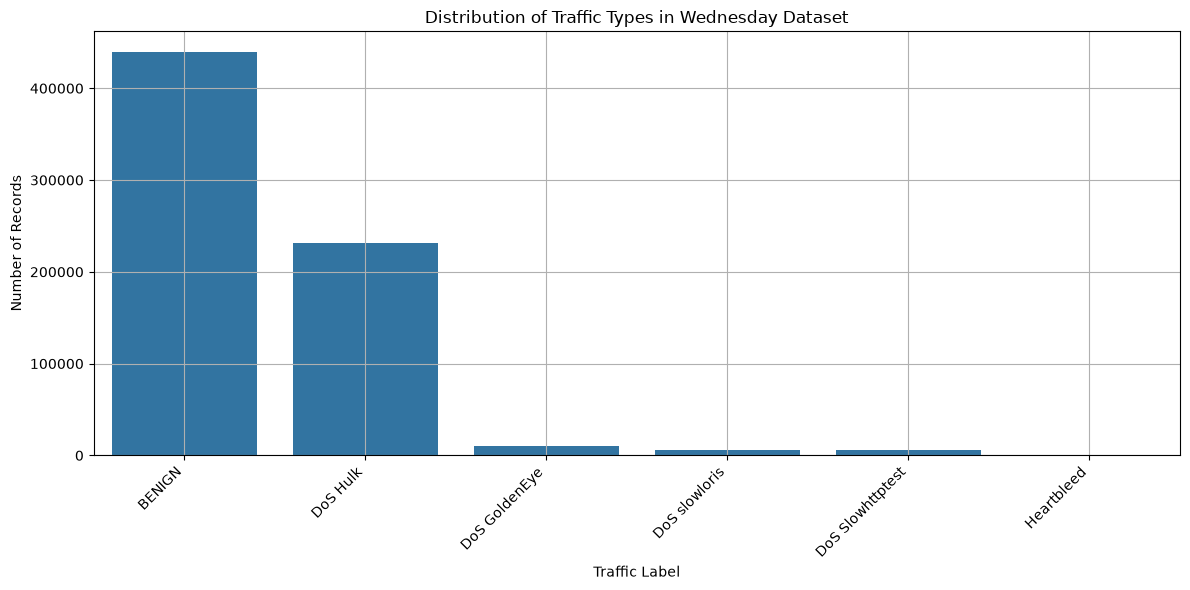

Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


In [ ]:
#CELL 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = os.getenv('DATA_DIR')
df = pd.read_csv(DATA_DIR)

#clean column name if needed
df.columns = df.columns.str.strip()

#clean label values
df['Label'] = df['Label'].str.strip()

#get distribution
label_counts = df['Label'].value_counts()

#plot
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Traffic Types in Wednesday Dataset")
plt.xlabel("Traffic Label")
plt.ylabel("Number of Records")
plt.grid(True)
plt.tight_layout()
plt.show()

#shows class ratios
print(label_counts)


In [10]:
#CELL 2



#drop IPs, ports, IDs, etc.                 because they might cause data leakage
columns_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Fwd Header Length.1']  # adjust as needed

for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

#drop constant columns(same value or not unique value for every row)
nunique = df.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
df.drop(constant_cols, axis=1, inplace=True)

#print remaining columns
print(f"Remaining columns: {df.columns.tolist()}")


Remaining columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Avg Fw

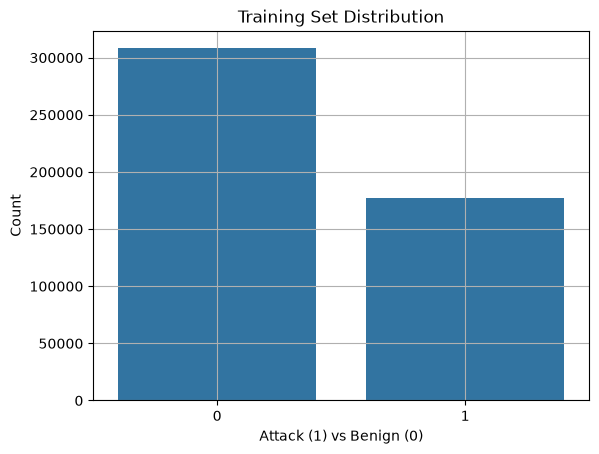

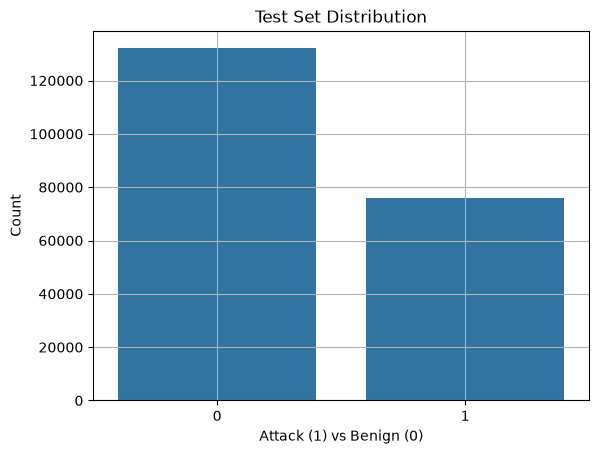

In [11]:
#CELL 3


import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(DATA_DIR)
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].str.strip()

#convert to binary classification
df['Attack'] = df['Label'].apply(lambda x: 0 if x == "BENIGN" else 1)

#drop irrelevant or leaking columns
columns_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Fwd Header Length.1']
for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

#drop constant columns
constant_cols = df.columns[df.nunique() <= 1]
df.drop(constant_cols, axis=1, inplace=True)

#separate features and label
X = df.drop(['Label', 'Attack'], axis=1)
y = df['Attack']

#split into train/test with stratification to preserve class balance
#%30 goes to test also the ratio of attack and benign is protetcted
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#show class distribution in each set
def plot_distribution(y_data, title):
    sns.countplot(x=y_data)
    plt.title(title)
    plt.xlabel("Attack (1) vs Benign (0)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

plot_distribution(y_train, "Training Set Distribution")
plot_distribution(y_test, "Test Set Distribution")


In [ ]:
#CELL 4


import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

#inject artificial missingness into X_train
def inject_missingness(X, missing_fraction=0.1, random_state=42):
    X_missing = X.copy()
    np.random.seed(random_state)
    mask = np.random.rand(*X_missing.shape) < missing_fraction
    X_missing = X_missing.mask(mask)
    return X_missing

X_train_missing = inject_missingness(X_train, missing_fraction=0.1)

X_train_missing.replace([np.inf, -np.inf], np.nan, inplace=True)#there are infinity values in the dataset so convert them to NaN


#imputation strategies
imputers = {
    "Mean": SimpleImputer(strategy='mean'),
    "KNN": KNNImputer(n_neighbors=5),
    "Iterative": IterativeImputer(random_state=42)
}

#train and evaluate a Random Forest for each imputed version
results = []

for name, imputer in imputers.items():
    print(f"\n▶ Imputation Strategy: {name}")

    #imputer → Scaler → Classifier
    pipeline = make_pipeline(
        imputer,
        StandardScaler(),
        RandomForestClassifier(random_state=42)
    )

    # Fit on training data with missingness
    pipeline.fit(X_train_missing, y_train)

    X_test.replace([np.inf, -np.inf], np.nan, inplace=True)#change all inf to NaN


    # Predict on clean test data
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")

    results.append({
        "Imputation": name,
        "Accuracy": acc,
        "F1": f1,
        "ROC-AUC": auc
    })

#summarize results
results_df = pd.DataFrame(results)
print("\n Summary:")
print(results_df)






#Took 30 more than 30 minutes so maybe use a smaller sample like below



▶ Imputation Strategy: Mean


In [ ]:
#CELL 5


import pandas as pdn  #10k rows
import numpy as np
from sklearn.experimental import enable_iterative_imputer  # required for IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer  # you can add Iterative later if needed
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#take stratified sample from train set
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=10000, stratify=y_train, random_state=42
)

#clean inf/-inf from X_train_sample and X_test
X_train_sample.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

#inject artificial missingness into X_train_sample
def inject_missingness(X, missing_fraction=0.1, random_state=42):
    X_missing = X.copy()
    np.random.seed(random_state)
    mask = np.random.rand(*X_missing.shape) < missing_fraction
    return X_missing.mask(mask)

#drrop rows with any missing values
def dropna_strategy(X_miss, y_original):
    mask = ~X_miss.isna().any(axis=1)
    return X_miss[mask], y_original[mask]


X_train_missing = inject_missingness(X_train_sample, missing_fraction=0.1)

#define imputation strategies
imputers = {
    "Mean": SimpleImputer(strategy='mean'),
    "KNN": KNNImputer(n_neighbors=5)
}

#train + evaluate
results = []

for name, imputer in imputers.items():
    print(f"\n▶ Imputation Strategy: {name}")

    pipeline = make_pipeline(
        imputer,
        StandardScaler(),
        RandomForestClassifier(random_state=42)
    )

    pipeline.fit(X_train_missing, y_train_sample)

    # Predict on clean (preprocessed) X_test
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")

    results.append({
        "Imputation": name,
        "Accuracy": acc,
        "F1": f1,
        "ROC-AUC": auc
    })

#evaluate "Drop Rows with Missing"
print("\n▶ Imputation Strategy: Drop Rows (Dropna)")
X_dropna, y_dropna = dropna_strategy(X_train_missing, y_train_sample)

pipeline = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

pipeline.fit(X_dropna, y_dropna)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")

results.append({
    "Imputation": "Drop Rows",
    "Accuracy": acc,
    "F1": f1,
    "ROC-AUC": auc
})

# Final results summary
results_df = pd.DataFrame(results)
print("\n Final Summary:")
print(results_df)






#so mean and knn are similar and better than dropping rows immediately. mean is faster and really close to knn so that might be an advantage

In [ ]:
#CELL 6


!pip install imbalanced-learn


In [ ]:
#CELL 7


import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#sample 10K rows from training set, stratified
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=10000, stratify=y_train, random_state=42
)

#inject missingness and clean inf
def inject_missingness(X, missing_fraction=0.1, random_state=42):
    X_missing = X.copy()
    np.random.seed(random_state)
    mask = np.random.rand(*X_missing.shape) < missing_fraction
    return X_missing.mask(mask)

X_train_missing = inject_missingness(X_train_sample, missing_fraction=0.1)
X_train_missing.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

#apply Mean Imputation
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_missing)
X_test_imputed = imputer.transform(X_test)

#define sampling strategies
samplers = {
    "No Sampling": None,
    "SMOTE": SMOTE(random_state=42),
    "Undersampling": RandomUnderSampler(random_state=42)
}

results = []

#loop over samplers
for name, sampler in samplers.items():
    print(f"\n Sampling Strategy: {name}")

    #sampling (only on train)
    if sampler is None:
        X_resampled, y_resampled = X_train_imputed, y_train_sample
    else:
        X_resampled, y_resampled = sampler.fit_resample(X_train_imputed, y_train_sample)

    #train model
    pipeline = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(random_state=42)
    )
    pipeline.fit(X_resampled, y_resampled)

    #evaluate on clean test set
    y_pred = pipeline.predict(X_test_imputed)
    y_proba = pipeline.predict_proba(X_test_imputed)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")

    results.append({
        "Sampling": name,
        "Accuracy": acc,
        "F1": f1,
        "ROC-AUC": auc
    })

#summary
results_df = pd.DataFrame(results)
print("\n Sampling Comparison Summary:")
print(results_df)



#undersampling is not worth: you lose data and dont gain enough performance. SMOTE is better but can be noisy and not worth to risk in this specific example.
#no sampling in this specific case is the most optimal way

In [ ]:
#CELL 8


#lets increase the missingness to %20 to see how things go in not ideal way. also double the size of training set(20K)
#still using mean imputation

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#sample 20K rows from training set, stratified
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=20000, stratify=y_train, random_state=42
)

#inject 20% missingness and clean infs
def inject_missingness(X, missing_fraction=0.2, random_state=42):
    X_missing = X.copy()
    np.random.seed(random_state)
    mask = np.random.rand(*X_missing.shape) < missing_fraction
    return X_missing.mask(mask)

X_train_missing = inject_missingness(X_train_sample, missing_fraction=0.2)
X_train_missing.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

#apply Mean Imputation
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_missing)
X_test_imputed = imputer.transform(X_test)

#define sampling strategies
samplers = {
    "No Sampling": None,
    "SMOTE": SMOTE(random_state=42),
    "Undersampling": RandomUnderSampler(random_state=42)
}

results = []

#loop over samplers
for name, sampler in samplers.items():
    print(f"\n Sampling Strategy: {name}")

    if sampler is None:
        X_resampled, y_resampled = X_train_imputed, y_train_sample
    else:
        X_resampled, y_resampled = sampler.fit_resample(X_train_imputed, y_train_sample)

    pipeline = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(random_state=42)
    )
    pipeline.fit(X_resampled, y_resampled)

    y_pred = pipeline.predict(X_test_imputed)
    y_proba = pipeline.predict_proba(X_test_imputed)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")

    results.append({
        "Sampling": name,
        "Accuracy": acc,
        "F1": f1,
        "ROC-AUC": auc
    })

#show results
results_df = pd.DataFrame(results)
print("\n Sampling Comparison Summary (20K rows, 20% missing):")
print(results_df)


In [ ]:
#CELL 9


#results are too close to compare so use fewer rows to train and increase the missingness(3K rows, %30)

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#stratified sample of 3K rows from training set
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=3000, stratify=y_train, random_state=42
)

#inject 30% missingness and clean infinities
def inject_missingness(X, missing_fraction=0.3, random_state=42):
    X_missing = X.copy()
    np.random.seed(random_state)
    mask = np.random.rand(*X_missing.shape) < missing_fraction
    return X_missing.mask(mask)

X_train_missing = inject_missingness(X_train_sample, missing_fraction=0.3)
X_train_missing.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

#mean imputation
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_missing)
X_test_imputed = imputer.transform(X_test)

#define samplers
samplers = {
    "No Sampling": None,
    "SMOTE": SMOTE(random_state=42),
    "Undersampling": RandomUnderSampler(random_state=42)
}

results = []

#train and evaluate each sampling strategy
for name, sampler in samplers.items():
    print(f"\n Sampling Strategy: {name}")

    if sampler is None:
        X_resampled, y_resampled = X_train_imputed, y_train_sample
    else:
        X_resampled, y_resampled = sampler.fit_resample(X_train_imputed, y_train_sample)

    pipeline = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(random_state=42)
    )
    pipeline.fit(X_resampled, y_resampled)

    y_pred = pipeline.predict(X_test_imputed)
    y_proba = pipeline.predict_proba(X_test_imputed)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")

    results.append({
        "Sampling": name,
        "Accuracy": acc,
        "F1": f1,
        "ROC-AUC": auc
    })

#results
results_df = pd.DataFrame(results)
print("\n Sampling Comparison Summary (3K rows, 30% missing):")
print(results_df)



#RESULT: by looking at the results of sampling comparisons we cans ee that for this specific case sampling does not matter that much.
#stratified sampling(the one we did at the beginning) was enough. because attack patterns were strong in this case. also ratio was already good at start.

In [ ]:
#CELL 10


!pip install xgboost


In [ ]:
#CELL 11



#Now we test the ml models: RandomForest, xgboost, logistic regression KNN
#rows 10K stratified, %20 missingness, mean imputation, no sampling
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

#stratified sample of 10K rows
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=10000, stratify=y_train, random_state=42
)

#inject 20% missingness
def inject_missingness(X, missing_fraction=0.2, random_state=42):
    X_missing = X.copy()
    np.random.seed(random_state)
    mask = np.random.rand(*X_missing.shape) < missing_fraction
    return X_missing.mask(mask)

X_train_missing = inject_missingness(X_train_sample, missing_fraction=0.2)
X_train_missing.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

#mean imputation
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_missing)
X_test_imputed = imputer.transform(X_test)

#define models to test
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

results = []

#evaluate each model
for name, model in models.items():
    print(f"\n Evaluating: {name}")

    pipeline = make_pipeline(
        StandardScaler(),
        model
    )
    pipeline.fit(X_train_imputed, y_train_sample)

    y_pred = pipeline.predict(X_test_imputed)
    y_proba = pipeline.predict_proba(X_test_imputed)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "ROC-AUC": auc
    })

#results
results_df = pd.DataFrame(results)
print("\n Model Comparison Summary:")
print(results_df)




#XGB(not tuned used with default) performs the best out of all. Random forest is close and easier, if speed matters can be used
#KNN is also good but not ideal compared to others for final version of project. Logistic is not preferred compared to others.

In [ ]:
#CELL 12


import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

#sample 10K rows, stratified
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=10000, stratify=y_train, random_state=42
)

#inject 10% missingness
def inject_missingness(X, missing_fraction=0.1, random_state=42):
    X_missing = X.copy()
    np.random.seed(random_state)
    mask = np.random.rand(*X_missing.shape) < missing_fraction
    return X_missing.mask(mask)

X_train_missing = inject_missingness(X_train_sample, missing_fraction=0.1)
X_train_missing.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

#mean imputation for missing values
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_missing)
X_test_imputed = imputer.transform(X_test)

#standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#XGBoost parameter sets for general testign to see how they peform
param_sets = [
    {"n_estimators": 50, "max_depth": 3, "learning_rate": 0.1, "subsample": 1.0},
    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators": 150, "max_depth": 7, "learning_rate": 0.01, "subsample": 0.7},
]

#evaluate each configuration
results = []
for i, params in enumerate(param_sets, 1):
    print(f"\n Testing Param Set {i}: {params}")
    model = XGBClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        subsample=params["subsample"],
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train_scaled, y_train_sample)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
    results.append({
        "Param Set": f"Set {i}",
        "Accuracy": acc,
        "F1": f1,
        "ROC-AUC": auc,
        **params
    })

#all results
results_df = pd.DataFrame(results)
print("\n XGBoost Tuning Summary:")
print(results_df)


#when we look at the result w ecan see that set 2 performed teh best

In [ ]:
#CELL 13


#Be careful with this OAT apprıach. It assumes that parameters are not interacting with eachother


import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

#prepare training/testing data (10K rows, 10% missing)
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=10000, stratify=y_train, random_state=42
)

def inject_missingness(X, missing_fraction=0.1, random_state=42):
    X_missing = X.copy()
    np.random.seed(random_state)
    mask = np.random.rand(*X_missing.shape) < missing_fraction
    return X_missing.mask(mask)

X_train_missing = inject_missingness(X_train_sample, 0.1)
X_train_missing.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_missing)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#baseline config choosen according to the reuslt from set2 before(we know it performed well but modified a bit)
baseline = {
    "n_estimators": 100,
    "max_depth": 5,
    "learning_rate": 0.1,
    "subsample": 1.0
}

#function to evaluate model
def evaluate_model(params):
    model = XGBClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        subsample=params["subsample"],
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train_scaled, y_train_sample)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    return acc, f1, auc

#one-at-a-time tuning
best_params = baseline.copy()
tuning_results = {}

# tune n_estimators
print("\n Tuning n_estimators")
for val in [50, 100, 150]:
    test_params = best_params.copy()
    test_params["n_estimators"] = val
    acc, f1, auc = evaluate_model(test_params)
    print(f"n_estimators={val} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    tuning_results[f"n_estimators={val}"] = f1
best_params["n_estimators"] = int(max(
    [(k, v) for k, v in tuning_results.items() if "n_estimators" in k],
    key=lambda x: x[1]
)[0].split("=")[1])

# tune max_depth
print("\n Tuning max_depth")
tuning_results.clear()
for val in [3, 5, 7]:
    test_params = best_params.copy()
    test_params["max_depth"] = val
    acc, f1, auc = evaluate_model(test_params)
    print(f"max_depth={val} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    tuning_results[f"max_depth={val}"] = f1
best_params["max_depth"] = int(max(
    [(k, v) for k, v in tuning_results.items() if "max_depth" in k],
    key=lambda x: x[1]
)[0].split("=")[1])

#tune learning_rate
print("\n Tuning learning_rate")
tuning_results.clear()
for val in [0.1, 0.05, 0.01]:
    test_params = best_params.copy()
    test_params["learning_rate"] = val
    acc, f1, auc = evaluate_model(test_params)
    print(f"learning_rate={val} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    tuning_results[f"learning_rate={val}"] = f1
best_params["learning_rate"] = float(max(
    [(k, v) for k, v in tuning_results.items() if "learning_rate" in k],
    key=lambda x: x[1]
)[0].split("=")[1])

# tune subsample
print("\n Tuning subsample")
tuning_results.clear()
for val in [1.0, 0.8, 0.7]:
    test_params = best_params.copy()
    test_params["subsample"] = val
    acc, f1, auc = evaluate_model(test_params)
    print(f"subsample={val} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    tuning_results[f"subsample={val}"] = f1
best_params["subsample"] = float(max(
    [(k, v) for k, v in tuning_results.items() if "subsample" in k],
    key=lambda x: x[1]
)[0].split("=")[1])

#final test with best params
print("\n Final Model with Tuned Hyperparameters:")
print(best_params)
final_acc, final_f1, final_auc = evaluate_model({
    "n_estimators": int(best_params["n_estimators"]),
    "max_depth": int(best_params["max_depth"]),
    "learning_rate": float(best_params["learning_rate"]),
    "subsample": float(best_params["subsample"])
})
print(f"\nFinal Performance → Acc: {final_acc:.4f} | F1: {final_f1:.4f} | AUC: {final_auc:.4f}")





#explanations of the result:
#n_estimators: more trees helped(150>100>50)
#max_depth:more depth performed well until 5. both 5 and 7 performed same. we look for performance not speed so 7 is okay
#learning_rate: 0.1 is best. 0.05 close but hurt the performnace because learning process was too slow
#subsample: all of them performed really similar. so no need to subset 1.0 is okay.

In [ ]:
#CELL 14


#From the data gathered above, we found the ideal parameters. We will use this parameters to test in a case where overfitting is less likely
#First train: Benign + Hulk Then test: DoS GoldenEye', 'Slowloris', 'Slowhttptest', 'Heartbleed' + Benign

In [ ]:
#CELL 15


import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from sklearn.utils import shuffle

df = pd.read_csv("DATA_DIR")
df.columns = df.columns.str.strip()

#drop known leakage columns
columns_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Fwd Header Length.1']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1, inplace=True)

#groups
attack_train = "DoS Hulk"
attack_test = ["DoS GoldenEye", "Slowloris", "Slowhttptest", "Heartbleed"]

#create training set: BENIGN + DoS Hulk
df_train = df[df["Label"].isin(["BENIGN", attack_train])].copy()
df_train["Label"] = df_train["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

#create test set: other DoS + same number of benign
df_dos_test = df[df["Label"].isin(attack_test)].copy()
df_dos_test["Label"] = 1  # all are attacks here but not DoS Hulk

n_dos_test = len(df_dos_test)
df_benign_test = df[df["Label"] == "BENIGN"].sample(n=n_dos_test, random_state=42)
df_benign_test["Label"] = 0

df_test = pd.concat([df_dos_test, df_benign_test])
df_test = shuffle(df_test, random_state=42)

#separate features/labels
X_train = df_train.drop("Label", axis=1)
y_train = df_train["Label"]
X_test = df_test.drop("Label", axis=1)
y_test = df_test["Label"]

#replace inf with nan
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

#handle misisng
imputer = SimpleImputer(strategy="mean")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#train XGBoost model
xgb = XGBClassifier(
    n_estimators=150,
    max_depth=7,
    learning_rate=0.1,
    subsample=1.0,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_scaled, y_train)

#predict and result
y_pred = xgb.predict(X_test_scaled)
y_proba = xgb.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n Realistic Intra-DoS + Benign Test (Balanced):")
print(f"Train on: {attack_train} + BENIGN | Test on: {attack_test} + BENIGN")
print(f"Training samples: {len(y_train)} | Testing samples: {len(y_test)}")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")


In [ ]:
#CELL 16


df_train["Label"].value_counts()#train data ratio



In [ ]:
#CELL 17


df_test["Label"].value_counts()#test data ratio

In [ ]:
#CELL 18


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Attack"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Realistic DoS Test)")
plt.show()


In [ ]:
#CELL 19


import matplotlib.pyplot as plt
import numpy as np

#plot feature importances from trained XGBoost model
importances = xgb.feature_importances_
feature_names = X_train.columns

#sort features by importance
indices = np.argsort(importances)[::-1]
top_n = 20  # top 20 features

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importances[indices[:top_n]][::-1])
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1])
plt.xlabel("Feature Importance Score")
plt.title("Top 20 Important Features (XGBoost)")
plt.tight_layout()
plt.show()


In [ ]:
#CELL 20


import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from sklearn.utils import shuffle

# load and clean
df = pd.read_csv("DATA_DIR")
df.columns = df.columns.str.strip()
columns_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Fwd Header Length.1']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1, inplace=True)

# define attacks
attack_train = "DoS Hulk"
attack_test = ["DoS GoldenEye", "Slowloris", "Slowhttptest", "Heartbleed"]

# create BALANCED training set (equal BENIGN + DoS Hulk)
df_hulk = df[df["Label"] == attack_train].copy()
df_benign_train = df[df["Label"] == "BENIGN"].sample(n=len(df_hulk), random_state=42)

df_train = pd.concat([df_benign_train, df_hulk])
df_train["Label"] = df_train["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)
df_train = shuffle(df_train, random_state=42)

#create BALANCED test set (other DoS + same number of benign)
df_dos_test = df[df["Label"].isin(attack_test)].copy()
df_dos_test["Label"] = 1
df_benign_test = df[df["Label"] == "BENIGN"].sample(n=len(df_dos_test), random_state=42)
df_benign_test["Label"] = 0

df_test = pd.concat([df_dos_test, df_benign_test])
df_test = shuffle(df_test, random_state=42)

# prepare features & labels
X_train = df_train.drop("Label", axis=1)
y_train = df_train["Label"]
X_test = df_test.drop("Label", axis=1)
y_test = df_test["Label"]

#save feature names used during training for real-time inference
with open("features.txt", "w") as f:
    f.write("\n".join(X_train.columns))


#replace inf and handle missing
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
imputer = SimpleImputer(strategy="mean")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#train XGBoost model
xgb = XGBClassifier(
    n_estimators=150,
    max_depth=7,
    learning_rate=0.1,
    subsample=1.0,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_scaled, y_train)

#evaluate
y_pred = xgb.predict(X_test_scaled)
y_proba = xgb.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n Balanced Train & Test (1:1 Benign vs Attack):")
print(f"Train on: {attack_train} + BENIGN | Test on: {attack_test} + BENIGN")
print(f"Training samples: {len(y_train)} | Testing samples: {len(y_test)}")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")




In [ ]:
#CELL 21



from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Attack"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Balanced Train & Test")
plt.show()




#True/Predicted=False Positive, True Negative, ...

#benign/benign=TP
#benign/attack=FN
#attack/benign=FP
#attack/attack=TN

In [ ]:
#CELL 22


import numpy as np

#get feature importances from XGBoost
importances = xgb.feature_importances_
feature_names = X_train.columns

#sortt top 20
indices = np.argsort(importances)[::-1]
top_n = 20

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importances[indices[:top_n]][::-1])
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Important Features (Balanced XGBoost)")
plt.tight_layout()
plt.show()


In [ ]:
#CELL 23



print("\nLabel distribution in training set:")
print(y_train.value_counts().rename(index={0: "BENIGN", 1: "ATTACK"}))

print("\nLabel distribution in test set:")
print(y_test.value_counts().rename(index={0: "BENIGN", 1: "ATTACK"}))


In [ ]:
#CELL 24



#retrain XGBoost with Top 40 Selected Features
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from sklearn.utils import shuffle
import joblib

#load and clean
df = pd.read_csv("DATA_DIR")
df.columns = df.columns.str.strip()
columns_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Fwd Header Length.1']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1, inplace=True)

#define top 40 selected features (no duplicates be carfeul)
selected_features = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count'
]

# filter dataset to selected features + Label
available_features = [f for f in selected_features if f in df.columns]
df = df[available_features + ['Label']]

#define attack categories
attack_train = "DoS Hulk"
attack_test = ["DoS GoldenEye", "Slowloris", "Slowhttptest", "Heartbleed"]

#create balanced training set
df_hulk = df[df["Label"] == attack_train].copy()
df_benign_train = df[df["Label"] == "BENIGN"].sample(n=len(df_hulk), random_state=42)
df_train = pd.concat([df_benign_train, df_hulk])
df_train["Label"] = df_train["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)
df_train = shuffle(df_train, random_state=42)

#create balanced test set
df_dos_test = df[df["Label"].isin(attack_test)].copy()
df_dos_test["Label"] = 1
df_benign_test = df[df["Label"] == "BENIGN"].sample(n=len(df_dos_test), random_state=42)
df_benign_test["Label"] = 0
df_test = pd.concat([df_dos_test, df_benign_test])
df_test = shuffle(df_test, random_state=42)

#prepare X/y
X_train = df_train.drop("Label", axis=1)
y_train = df_train["Label"]
X_test = df_test.drop("Label", axis=1)
y_test = df_test["Label"]

#save feature names
with open("features.txt", "w") as f:
    f.write("\n".join(X_train.columns))

#handle inf and NaNs
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
imputer = SimpleImputer(strategy="mean")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#train XGBoost
xgb = XGBClassifier(
    n_estimators=150,
    max_depth=7,
    learning_rate=0.1,
    subsample=1.0,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_scaled, y_train)

#evaluate
y_pred = xgb.predict(X_test_scaled)
y_proba = xgb.predict_proba(X_test_scaled)[:, 1]
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n Balanced Train & Test (1:1 Benign vs Attack):")
print(f"Train on: {attack_train} + BENIGN | Test on: {attack_test} + BENIGN")
print(f"Training samples: {len(y_train)} | Testing samples: {len(y_test)}")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")

#save model and scaler
joblib.dump(xgb, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")
